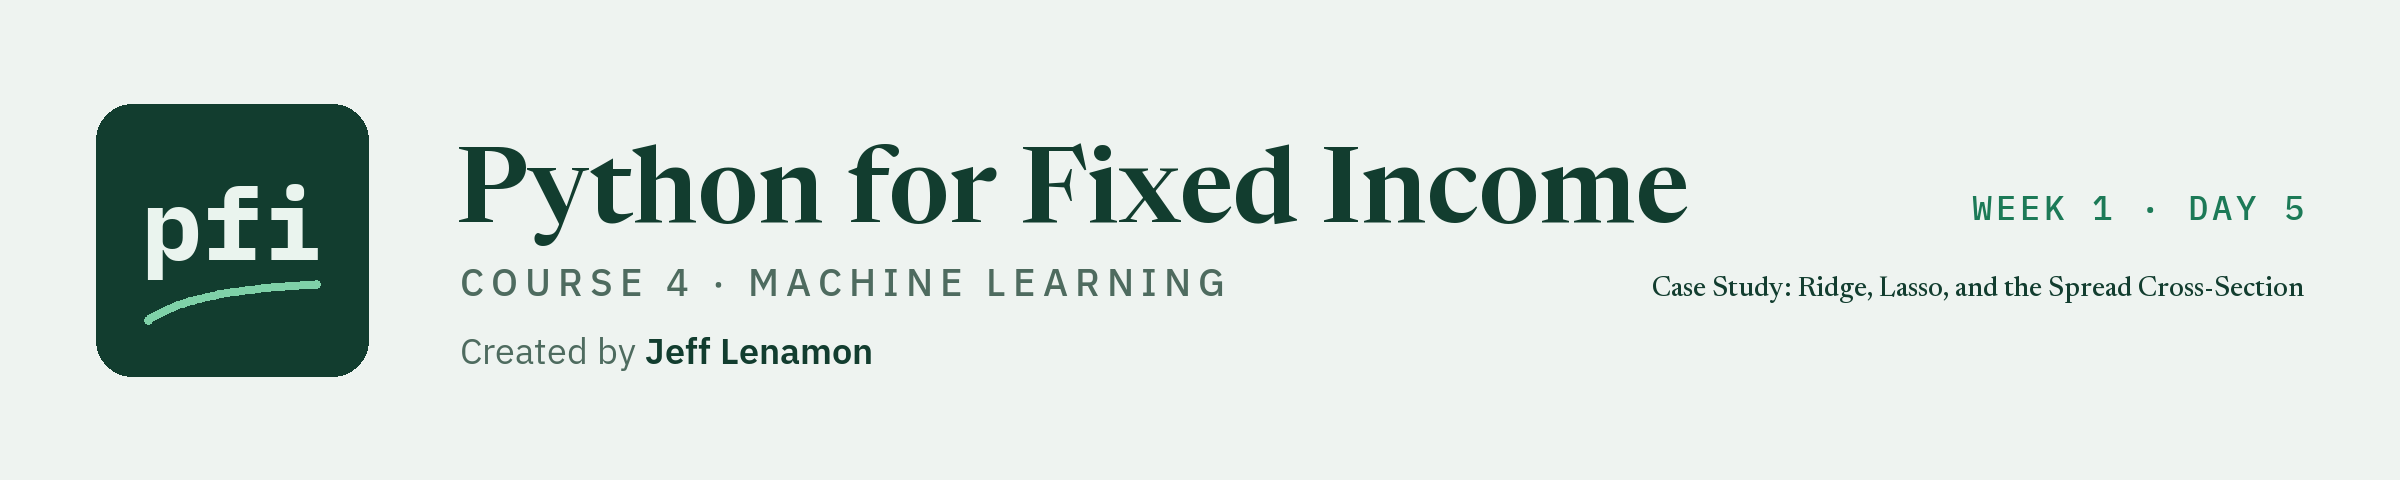

# Case Study: Ridge, Lasso, and the Spread Cross-Section

Week 1, Day 5. The last day of week 1: ridge and lasso inside a pipeline that fits its scaling on training rows only, the penalty chosen by cross-validation without touching the test rows, then a case study on the whole spread cross-section that ends with what the model shows, and where it fails.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day5/05_case_study_ridge_lasso_and_the_spread_cross_section.ipynb)

Four days have built a regression of OAS on a bond's characteristics: one feature on day 1, dummies on day 2, inference on day 3, the log of OAS on day 4. Every model so far was fitted by ordinary least squares (OLS), which makes the training errors as small as it can and nothing else. Today adds two models that also keep their coefficients small: **ridge** and **lasso**. They need two things the week has not used yet, scaling and a way to choose a setting, and both bring a new chance to leak. So today also brings the tool that keeps every fitted step on the training rows: scikit-learn's **`Pipeline`**.

The second half is the week 1 case study: one question, every feature the file offers, three models, two ways to split, and an honest account of the result. That result is plain, and the notebook says it up front: **on this benchmark, ridge and lasso do not beat plain regression.** Section 5.8 shows by how little the three differ, and section 5.11 says where the methods earn their place.

**The data is synthetic.** The 821 bonds of `benchmark.csv` belong to invented issuers, and their spreads were generated by the course's own script, `tools/make_holdings.py`, from each bond's rating, its maturity, an effect shared by each issuer's bonds, and random noise. Sector plays no part in that recipe. A model on these bonds recovers part of the recipe and nothing about any real market; section 5.10 puts the recipe's own numbers beside the fitted ones.

Today you will:

1. Fit ridge and lasso, and see what the penalty and its strength, alpha, do to coefficients.
2. Show why a penalty makes scaling matter.
3. Build a `Pipeline` with a `ColumnTransformer` that encodes and scales on training rows only, and label its coefficients with `named_coefficients`.
4. Choose alpha with `RidgeCV` and `LassoCV`, by cross-validation inside the training rows.
5. See which coefficients lasso sets to zero, and why on these bonds.
6. Run the week 1 case study: three models, the random split against the split by issuer, the generator's table beside the fitted one, and what the model shows, and where it fails.

Q. Set up today's work folder: the thread settings, the seed, and today's three data files.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_05_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_05_q4y62a0y, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests']


* The module and its tests as day 4 left them: 6 functions and 17 tests. `_as_1d_array` is a helper and is not counted. By the end of today there are 7 functions and 20 tests.

Q. Load the bonds, and add the three columns today needs: the log of OAS, the years to maturity, and the amount outstanding in billions.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [5]:
# the 821 synthetic benchmark bonds, with their dates read as dates, and the rating table
bench = pd.read_csv("benchmark.csv", parse_dates=["as_of_date", "maturity"], float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
assert bench["score"].notna().all(), "a bond has a rating that ratings.csv does not list"

# the target: the natural log of OAS in bp (day 4)
bench["log_oas"] = np.log(bench["oas"])
# years to maturity from the file's as-of date, in years of 365.25 days
bench["years"] = (bench["maturity"] - bench["as_of_date"]).dt.days / 365.25
# amount outstanding in billions of dollars, a size a reader can take in
bench["amount_bn"] = bench["amount_outstanding"] / 1e9

print(f"{len(bench):,} bonds of {bench['ticker'].nunique()} invented issuers")
bench[["cusip", "rating", "sector", "oas", "log_oas", "duration", "years", "coupon", "amount_bn"]].head()

821 bonds of 150 invented issuers


,cusip,rating,sector,oas,log_oas,duration,years,coupon,amount_bn
0,99001BAA4,BBB,Energy,83,4.418841,6.000,7.290897,4.875,2.40
1,99001BAB2,BBB,Energy,122,4.804021,6.834,8.854209,5.750,1.75
2,99001BAC0,BBB,Energy,123,4.812184,9.848,14.313484,5.000,0.30
3,99001BAD8,BBB,Energy,88,4.477337,0.933,0.963723,3.875,2.35
4,99001BAE6,BBB,Energy,127,4.844187,6.256,8.005476,5.375,1.55


* 821 bonds of 150 invented issuers. Every number fitted to them today describes the course's recipe.

Q. Split first: put the test rows away before anything is computed for a model.

In [6]:
from sklearn.model_selection import train_test_split

# the course split of days 1 to 4: a quarter of the bonds to the test set, SEED fixes which ones
bench_train, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
mlkit.assert_disjoint(bench_train.index, bench_test.index)

y_train, y_test = bench_train["log_oas"], bench_test["log_oas"]
print(f"training rows: {len(bench_train)}; test rows: {len(bench_test)}; no bond on both sides")

training rows: 615; test rows: 206; no bond on both sides


* The same 615 and 206 bonds as every day this week: splitting the whole table with the same seed picks the same rows as splitting `X` and `y` did. Every model below, in both halves of the notebook, is fitted on these training rows and reported on these test rows.

## 5.1 Shrinking Coefficients: Ridge and Lasso

OLS chooses the coefficients that make the sum of squared training errors as small as possible. Ridge and lasso add a **penalty** on the size of the coefficients, so a coefficient has to earn its size by reducing the errors:

| Model | Makes as small as possible | The penalty |
| --- | --- | --- |
| OLS (`LinearRegression`) | sum of squared errors | none |
| Ridge (`Ridge`) | sum of squared errors + alpha x (sum of squared coefficients) | squares: pulls every coefficient toward zero, rarely to exactly zero |
| Lasso (`Lasso`) | (sum of squared errors) / (2 x rows) + alpha x (sum of absolute coefficients) | absolute values: can set a coefficient to exactly zero |

* **alpha** is the strength of the penalty. At alpha 0 both are OLS; as alpha grows, the coefficients shrink. alpha is a **hyperparameter**: a setting chosen before the fit, not a number the fit estimates.
* The intercept is never penalized. It is the fitted value of a bond whose features are all at their average.
* The two penalties are written on different scales (lasso divides the errors by twice the number of rows), so an alpha for ridge and an alpha for lasso are not comparable numbers.
* Why accept bigger training errors? A coefficient fitted to the noise of 615 rows can be too large, and a smaller one can do better on rows the model never saw. Whether it does is a question for the data, and today's answer is in section 5.8.

Q. Fit OLS, ridge, and lasso of log OAS on three features: rating score, duration, and coupon. Scale the features first, and compare the coefficients.

In [7]:
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SMALL = ["score", "duration", "coupon"]
models = {"OLS": LinearRegression(), "ridge, alpha 10": Ridge(alpha=10), "lasso, alpha 0.05": Lasso(alpha=0.05)}

coefficients = {}
for name, model in models.items():
    # a pipeline of two steps: scale the three features, then fit the model (section 5.3 explains it)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", model)])
    pipeline.fit(bench_train[SMALL], y_train)
    # coef_ holds one coefficient per feature: log OAS per standard deviation of that feature
    coefficients[name] = pipeline["model"].coef_

pd.DataFrame(coefficients, index=SMALL).round(4)

,OLS,"ridge, alpha 10","lasso, alpha 0.05"
score,0.6065,0.5904,0.5640
duration,0.0384,0.0352,0.0000
coupon,0.1553,0.1641,0.1383


* Ridge shrinks the coefficients **as a group**: the sum of their squares falls from 0.3935 to 0.3767, and none reaches zero. Score and duration shrink; coupon grows a little. Score and coupon are correlated on the training rows (0.70), so when the penalty trims score, coupon takes up part of its share.
* Lasso at alpha 0.05 sets duration's coefficient, the smallest, to **exactly** 0.0000: the model no longer uses duration at all. At this alpha, what duration adds to the fit is not worth its penalty.
* The coefficients are per **standard deviation** of each feature, because the features were scaled: a one standard deviation difference in rating score goes with a 0.6065 difference in fitted log OAS in the OLS model, holding the other two fixed.

Q. How do the coefficients move as alpha grows?

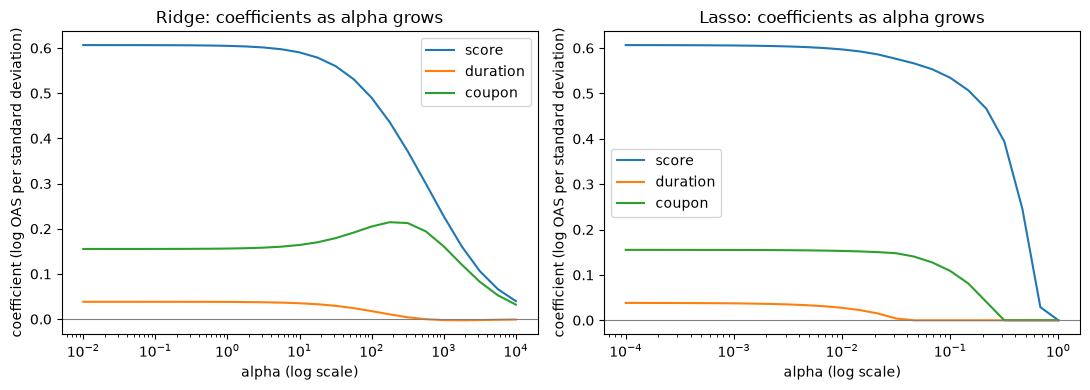

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (title, make_model, alphas) in zip(axes, [
        ("Ridge", lambda a: Ridge(alpha=a), np.logspace(-2, 4, 25)),
        ("Lasso", lambda a: Lasso(alpha=a), np.logspace(-4, 0, 25))]):
    # refit the same pipeline at each alpha and keep its three coefficients
    path = [Pipeline([("scale", StandardScaler()), ("model", make_model(a))]).fit(bench_train[SMALL], y_train)["model"].coef_
            for a in alphas]
    path = np.array(path)
    for j, feature in enumerate(SMALL):
        ax.plot(alphas, path[:, j], label=feature)
    ax.set_xscale("log")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(f"{title}: coefficients as alpha grows")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("coefficient (log OAS per standard deviation)")
    ax.legend()
plt.tight_layout()
plt.show()

* Left: ridge's coefficients glide toward zero together as alpha grows. Right: lasso's hit zero one at a time, and stay there. That is the whole difference between the two penalties, in one picture.
* At the far right both models have shrunk everything: every bond gets nearly the same fitted spread, the average. Somewhere between "no penalty" and "everything zero" is the alpha that does best on rows the model did not see; section 5.4 finds it without looking at the test rows.

## 5.2 Why Scaling Now Matters

OLS does not care about units: write the coupon in bp instead of percent and its coefficient divides by 100, while every fitted value stays the same. A penalty breaks that. It charges every coefficient by its size, and a coefficient's size depends on the unit of its feature: in bp, the coupon's coefficient is a hundred times smaller, so the penalty hardly touches it. The penalty would fall harder or softer on a feature depending on the unit someone happened to choose, for no reason a desk would accept.

Q. Fit ridge with the coupon in percent and in bp, without scaling and with it. How far apart are the fitted spreads?

In [9]:
# the same three features, with the coupon in bp instead of percent
coupon_in_bp = bench_train[SMALL].assign(coupon=bench_train["coupon"] * 100)

def fitted_bp(model, X):
    """Fit on the training rows of X and return the fitted spreads of the same rows in bp (exp of fitted log OAS)."""
    return np.exp(model.fit(X, y_train).predict(X))

makers = {"OLS, not scaled": lambda: LinearRegression(),
          "ridge alpha 100, not scaled": lambda: Ridge(alpha=100),
          "ridge alpha 100, scaled": lambda: Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=100))])}
for label, make in makers.items():
    difference = np.abs(fitted_bp(make(), bench_train[SMALL]) - fitted_bp(make(), coupon_in_bp)).max()
    print(f"{label:28} coupon in percent against bp: largest difference in a fitted spread {difference:.1f} bp")

OLS, not scaled              coupon in percent against bp: largest difference in a fitted spread 0.0 bp
ridge alpha 100, not scaled  coupon in percent against bp: largest difference in a fitted spread 21.7 bp
ridge alpha 100, scaled      coupon in percent against bp: largest difference in a fitted spread 0.0 bp


* OLS: no difference. Ridge without scaling: fitted spreads up to 21.7 bp apart, from nothing but the unit of the coupon. Its coupon coefficient is 0.0881 per percent written in percent, and 0.0982 per percent written in bp: in bp the penalty barely reaches it, so it keeps more of its size and takes part of score's. Ridge after scaling: no difference, because every feature is in standard deviations whatever unit it started in.
* `StandardScaler` subtracts each column's mean and divides by its standard deviation. It uses the **population** standard deviation (dividing by n, Excel's `STDEV.P`), not the sample one (n - 1, `STDEV.S`). The Excel section shows why that detail decides whether Excel's ridge matches Python's.
* A scaler **learns** two numbers per column, a mean and a standard deviation. Learned from which rows? That is the leak today's tool prevents.

## 5.3 `Pipeline` and `ColumnTransformer`: Fitted Inside, on Training Rows

The case study uses every feature the file offers: rating and sector (categories) and duration, years, coupon, and amount (numbers). Each kind needs its own preparation, and each preparation learns something from the rows it is fitted on:

| Step | What it learns | From which rows |
| --- | --- | --- |
| `OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore")` | the list of ratings and sectors, minus the two reference levels | training |
| `StandardScaler()` | each number's mean and standard deviation | training |
| the model | its coefficients and intercept | training |

* **`ColumnTransformer`** sends each list of columns to its own step and puts the results side by side.
* **`Pipeline`** chains the steps: `.fit` fits each step on the training rows in turn, and `.predict` sends any rows through the fitted steps. One `.fit(X_train, y_train)` and nothing can be fitted on the test rows by accident.
* `drop=["A", "Consumer"]` names the reference levels, as days 2 to 4 did with `rating_dummies`: rating A (the largest investment grade level) and sector Consumer (the alphabetically first, a choice). Each other level's coefficient is its difference from those.
* `handle_unknown="ignore"`: a level the training rows never saw gets zeros in every indicator, so the bond is treated as the reference level. Some levels are thin (AA+ has 4 bonds, CCC 3), and section 5.9 meets this case.

Q. Write a function that builds the case study's pipeline around any model.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

CAT = ["rating", "sector"]
NUM = ["duration", "years", "coupon", "amount_bn"]
FEATURES = CAT + NUM

def build_pipeline(model, issuer=False, numbers=NUM):
    """The case study's steps: rating and sector one-hot with references A and Consumer, the numbers scaled,
    then model. With issuer=True, one indicator column per issuer ticker is added (section 5.9 only); numbers
    replaces the list of number columns (section 5.10 only)."""
    parts = [("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), CAT)]
    if issuer:
        parts.append(("issuer", OneHotEncoder(handle_unknown="ignore"), ["ticker"]))
    parts.append(("numbers", StandardScaler(), numbers))
    return Pipeline([("encode", ColumnTransformer(parts)), ("model", model)])

X_train, X_test = bench_train[FEATURES], bench_test[FEATURES]
ols = build_pipeline(LinearRegression())
# one fit: the encoder, the scaler, and the model all learn from the training rows only
ols.fit(X_train, y_train)

names = ols[:-1].get_feature_names_out()
print(f"{len(names)} columns go into the model; the first three and the last four:")
print(list(names[:3]) + ["..."] + list(names[-4:]))

30 columns go into the model; the first three and the last four:
['categories__rating_A+', 'categories__rating_A-', 'categories__rating_AA', '...', 'numbers__duration', 'numbers__years', 'numbers__coupon', 'numbers__amount_bn']


* 30 columns: 17 rating indicators (18 levels less the reference A), 9 sector indicators (10 sectors less Consumer), and the 4 scaled numbers. `ols[:-1]` is every step but the last, and `get_feature_names_out()` names what comes out of it, each name led by its step's name.

Q. Which rows did the scaler learn from?

In [11]:
# the fitted scaler inside the pipeline: named_transformers_ holds each fitted step of the ColumnTransformer
scaler = ols["encode"].named_transformers_["numbers"]
print(f"scaler means equal the training rows' means: {np.allclose(scaler.mean_, X_train[NUM].mean(), rtol=0, atol=1e-12)}")
print(f"scaler means equal all {len(bench)} rows' means: {np.allclose(scaler.mean_, bench[NUM].mean(), rtol=0, atol=1e-6)}")
pd.DataFrame({"scaler mean": scaler.mean_, "scaler standard deviation (population)": scaler.scale_}, index=NUM).round(4)

scaler means equal the training rows' means: True
scaler means equal all 821 rows' means: False


,scaler mean,scaler standard deviation (population)
duration,5.9176,3.2209
years,8.7625,6.7868
coupon,5.8728,1.6964
amount_bn,1.3937,0.6567


* The training rows, and only them. When the pipeline later gives a fitted value for a test bond, it subtracts the **training** mean and divides by the **training** standard deviation: the test bonds are scaled with numbers they had no part in.

Q. The model's coefficients are a plain array, `ols["model"].coef_`, in the order of `names`. Add `named_coefficients` to `mlkit.py`, so a coefficient is never read without its name. Read the docstring before you run the cell.

In [12]:
%%writefile -a mlkit.py


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")

Appending to mlkit.py


* The model is the last step; the names come from everything before it, `pipeline[:-1]`. The function refuses a model with no `coef_` (a tree has none), and a count of coefficients that does not match the count of names, rather than pairing them wrongly.
* The docstring states the unit: per unit of each feature **as the model saw it**, so per standard deviation for a scaled number and per indicator for a rating or sector.

Q. Add the three tests: the names line up, a tree is refused, and the scaler inside a pipeline learns from the training rows only.

In [13]:
%%writefile -a test_mlkit.py


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)

Appending to test_mlkit.py


* `spread_pipeline` is a test helper, a smaller version of `build_pipeline` with two numbers.
* `test_pipeline_scaler_fitted_on_train_only` is the rule of this section written as a test: the scaler's means and standard deviations equal the training rows', and not all rows'.

Q. Reload the module and run all the tests.

In [14]:
importlib.reload(mlkit)
print(f"named_coefficients in mlkit: {hasattr(mlkit, 'named_coefficients')}")

named_coefficients in mlkit: True


In [15]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....................                                                     [100%]
20 passed in 1.98s



* `20 passed`: the 17 from days 1 to 4 and today's 3.

Q. Read the OLS model's coefficients by name: the four numbers and the three largest rating effects.

In [16]:
ols_coef = mlkit.named_coefficients(ols)
print("numbers (log OAS per standard deviation):")
print(ols_coef[ols_coef.index.str.startswith("numbers__")].round(4).to_string())
print("largest rating effects (log OAS against an A-rated bond):")
print(ols_coef[ols_coef.index.str.startswith("categories__rating_")].nlargest(3).round(4).to_string())

numbers (log OAS per standard deviation):
numbers__duration     0.0768
numbers__years       -0.0462
numbers__coupon       0.1706
numbers__amount_bn    0.0063
largest rating effects (log OAS against an A-rated bond):
categories__rating_CCC+    1.8538
categories__rating_B-      1.5505
categories__rating_CCC     1.5054


* A rating coefficient is in log OAS against an A-rated bond, holding the other features fixed: `rating_CCC+` at 1.8538 goes with a fitted spread about 538 percent wider than an A-rated bond's, 100 x (exp(b) - 1) as on day 4.
* These describe the training rows of a synthetic file. "Goes with" is all a coefficient says, never "causes".

Q. `cross_val_score` and `cross_validate` split the training rows into folds and fit on each. With a pipeline, is the scaler refitted in each fold?

In [17]:
from sklearn.model_selection import KFold, cross_validate

# five folds of the training rows, shuffled once with SEED
folds = KFold(5, shuffle=True, random_state=SEED)
# return_estimator keeps each fold's fitted pipeline; return_indices keeps each fold's rows
result = cross_validate(build_pipeline(LinearRegression()), X_train, y_train, cv=folds,
                        return_estimator=True, return_indices=True)

rows = []
for fold, (fitted_pipeline, fit_rows) in enumerate(zip(result["estimator"], result["indices"]["train"]), start=1):
    duration_mean = fitted_pipeline["encode"].named_transformers_["numbers"].mean_[0]
    rows.append({"fold": fold, "rows fitted": len(fit_rows), "scaler mean of duration": round(duration_mean, 4),
                 "mean of duration in those rows": round(X_train["duration"].iloc[fit_rows].mean(), 4)})
pd.DataFrame(rows).set_index("fold")

,rows fitted,scaler mean of duration,mean of duration in those rows
fold,,,
1,492,5.9015,5.9015
2,492,5.9824,5.9824
3,492,5.9270,5.9270
4,492,5.8450,5.8450
5,492,5.9320,5.9320


* Five folds, five scalers, each fitted on that fold's own rows and none on the rows the fold holds out. That is what a pipeline buys inside cross-validation: the held-out fold is scaled with numbers it had no part in, exactly as the test rows are.
* Scale the training rows once, outside a pipeline, then cross-validate the model alone, and every fold's held-out rows would have helped compute the mean they are scaled with. Today's AI check is the same mistake made with the test rows.

## 5.4 Choosing Alpha by Cross-Validation, Inside the Training Rows

alpha is chosen, and the test rows must play no part in choosing it. Week 1 has two roles of rows, training and test, so the choice is made by **cross-validation inside the training rows**: each candidate alpha is fitted on four folds and scored on the fifth, five times, and the alpha with the best average score wins. The test rows stay put away.

Q. Do it by hand first: score a grid of alphas for ridge, each with the whole pipeline refitted in every fold.

In [18]:
from sklearn.model_selection import cross_val_score

# 13 candidate alphas, from 0.001 to 1,000, evenly spaced on a log scale
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

scores = {}
for alpha in RIDGE_ALPHAS:
    # cross_val_score refits the whole pipeline in each fold and returns each fold's R-squared on its held-out rows
    scores[alpha] = cross_val_score(build_pipeline(Ridge(alpha=alpha)), X_train, y_train, cv=folds).mean()
by_hand = pd.Series(scores, name="mean R-squared on held-out folds (log OAS)").rename_axis("alpha")
print(f"best alpha by hand: {by_hand.idxmax():g}")
by_hand.round(4).to_frame()

best alpha by hand: 0.0316228


,mean R-squared on held-out folds (log OAS)
alpha,
0.001000,0.8972
0.003162,0.8972
0.010000,0.8972
0.031623,0.8973
0.100000,0.8972
0.316228,0.8956
1.000000,0.8854
3.162278,0.8505
10.000000,0.7835


* The best alpha is 0.0316228, near the small end of the grid, and from 0.001 to 0.1 the score hardly moves (every value is 0.8972 or 0.8973). From 1 upward it falls away (0.8854 at 1, 0.3369 at 1,000): shrinking these coefficients costs more than it saves.

Q. `RidgeCV` does the same search in one fit. Put it in the pipeline: does it choose the same alpha?

In [19]:
from sklearn.linear_model import LassoCV, RidgeCV

# RidgeCV tries every alpha with the same folds, keeps the best, then refits on all the training rows
ridge = build_pipeline(RidgeCV(alphas=RIDGE_ALPHAS, cv=folds))
ridge.fit(X_train, y_train)
print(f"RidgeCV chose alpha {ridge['model'].alpha_:g}; the same as by hand: {ridge['model'].alpha_ == by_hand.idxmax()}")

RidgeCV chose alpha 0.0316228; the same as by hand: True


* The same alpha, 0.0316228. One difference is worth knowing. In the loop, the whole pipeline was refitted in every fold, scaler included. With `RidgeCV` inside the pipeline, the scaler is fitted once on all the training rows and `RidgeCV` runs its folds on the scaled columns, so each held-out fold helped compute the mean it is scaled with. A mean and a standard deviation of 600 rows barely move when a fifth of them are left out, and here the choice is the same. Week 2 searches over a whole pipeline with `GridSearchCV`, which refits every step in every fold.

Q. Now lasso. `LassoCV` with no grid makes its own: 100 alphas from the smallest alpha that sets every coefficient to zero down to one thousandth of it. Which alpha does it choose?

In [20]:
# LassoCV with its own grid of alphas
lasso_default = build_pipeline(LassoCV(cv=folds, random_state=SEED)).fit(X_train, y_train)
own_grid = lasso_default["model"].alphas_
print(f"its grid: {own_grid.max():.6g} down to {own_grid.min():.6g}")
print(f"chosen alpha: {lasso_default['model'].alpha_:.6g}; the smallest on its grid: {lasso_default['model'].alpha_ == own_grid.min()}")

its grid: 0.581227 down to 0.000581227
chosen alpha: 0.000581227; the smallest on its grid: True


* It chose the **smallest** alpha it tried. A choice at the edge of a grid says only that the best alpha may lie beyond it, so the grid must be widened before the choice means anything. That is a check worth making every time a search returns an end point.

Q. Give `LassoCV` a wider grid, from 0.00001 to 1. Is the choice inside it now?

In [21]:
# 21 candidate alphas, from 0.00001 to 1, evenly spaced on a log scale
LASSO_ALPHAS = np.logspace(-5, 0, 21)
lasso = build_pipeline(LassoCV(alphas=LASSO_ALPHAS, cv=folds, random_state=SEED))
lasso.fit(X_train, y_train)
chosen = lasso["model"].alpha_
position = int(np.argmin(np.abs(LASSO_ALPHAS - chosen)))
print(f"LassoCV chose alpha {chosen:.6g}: number {position + 1} of {len(LASSO_ALPHAS)} on the grid, "
      f"inside it: {LASSO_ALPHAS.min() < chosen < LASSO_ALPHAS.max()}")

LassoCV chose alpha 0.000177828: number 6 of 21 on the grid, inside it: True


* 0.000177828, number 6 of 21, inside the grid. Like ridge's, it is small: cross-validation asks for very little penalty on these bonds. That is the first hint of the case study's result.
* `random_state=SEED` is passed to `LassoCV` as the course passes it to everything that takes one. With its default settings `LassoCV` updates coefficients in a fixed order and uses no randomness; the seed matters only if it is told to pick them at random.

## 5.5 Lasso Sets Coefficients to Zero: Which Ones, and Why Here

Q. At the alpha cross-validation chose, which coefficients did lasso set to exactly zero?

In [22]:
lasso_coef = mlkit.named_coefficients(lasso)
set_to_zero = lasso_coef[lasso_coef == 0.0]
print(f"{len(set_to_zero)} of {len(lasso_coef)} coefficients set to exactly zero: {list(set_to_zero.index)}")

1 of 30 coefficients set to exactly zero: ['categories__sector_Technology']


* 1 of 30, and it is a sector: `sector_Technology`. At this small alpha lasso is close to OLS and drops only what is worth least.

Q. As alpha grows, which coefficients go first?

In [23]:
groups = {"rating": "categories__rating_", "sector": "categories__sector_", "number": "numbers__"}
rows = []
for alpha in [0.001, 0.003, 0.01, 0.03]:
    coef = mlkit.named_coefficients(build_pipeline(Lasso(alpha=alpha)).fit(X_train, y_train))
    zero = coef[coef == 0.0].index
    row = {"alpha": alpha}
    for group, prefix in groups.items():
        row[f"{group} columns at zero"] = f"{zero.str.startswith(prefix).sum()} of {coef.index.str.startswith(prefix).sum()}"
    row["numbers at zero"] = ", ".join(name.removeprefix("numbers__") for name in zero if name.startswith("numbers__")) or "none"
    rows.append(row)
pd.DataFrame(rows).set_index("alpha")

,rating columns at zero,sector columns at zero,number columns at zero,numbers at zero
alpha,,,,
0.001,0 of 17,2 of 9,0 of 4,none
0.003,0 of 17,3 of 9,1 of 4,years
0.010,6 of 17,6 of 9,1 of 4,years
0.030,16 of 17,9 of 9,2 of 4,"years, amount_bn"


* At alpha 0.003 lasso has set four coefficients to zero: three sectors (`sector_Energy`, `sector_Materials` and `sector_Technology`) and **years**. No rating has gone. At 0.01 the ratings start to go too (6 of 17), and section 5.4 showed that much penalty costs accuracy.

**Why these, on these bonds.** The generator explains the order, because the course wrote it:

* **Sector plays no part in the recipe.** The sector coefficients are fitting noise, so they are small, and lasso drops them first. Day 3 found their p-values large for the same reason.
* **Years and duration carry the same information.** On the training rows their correlation is 0.95: both measure how long the bond has to run. The recipe uses maturity once, and the model needs it once, so lasso keeps one of the pair (duration) and drops the other.
* **Ratings carry the recipe's largest term**, the base spread for each rating, so they are the last to go.

Lasso's zeros are a description of these rows: a feature at zero added too little, at this alpha, to be worth its penalty. They are not a finding that the feature is unrelated to spreads in general, and with two closely related features, which one lasso keeps can turn on small differences in the rows.

## Case Study: Ridge, Lasso, and the Spread Cross-Section

### Context

A colleague has the course's benchmark, 821 invented bonds, and asks the question week 1 has been building toward: how much of the spread cross-section do a bond's rating, sector, duration, years to maturity, coupon, and size account for, how far off is a model of them on bonds it never saw, and does adding a penalty help? The bonds and their spreads are synthetic: the file was generated by the course's own script, so every answer below describes that recipe, and the notebook can check the answers against it.

### Objective

1. Fit three models of log OAS on the same features and the same training rows: OLS, ridge, and lasso, each penalty chosen by cross-validation on the training rows.
2. Compare them on the test rows, used once, by test MAE in bp (the course's main number) with R-squared beside it.
3. Measure how much one split moves the numbers, so a difference between models can be read against it.
4. Split by issuer as well as at random, and say which split answers which question.
5. Put the fitted rating effects beside the generator's own table.
6. Close with what the model shows, and where it fails.

### Data dictionary

| Column | Meaning | Unit | Role |
| --- | --- | --- | --- |
| `oas` | option-adjusted spread, generated | bp | target, as `log_oas` |
| `log_oas` | natural log of `oas` | log of bp | target |
| `rating` | one of 18 levels, AAA to CCC | category | feature, reference A |
| `sector` | one of 10 sectors | category | feature, reference Consumer |
| `duration` | modified duration | years | feature, scaled |
| `years` | years to maturity from the as-of date, days / 365.25 | years | feature, scaled |
| `coupon` | annual coupon | percent | feature, scaled |
| `amount_bn` | amount outstanding | billions of dollars | feature, scaled |
| `ticker` | the issuer's code | category | groups for the issuer split (section 5.9) |

### Overview, and where the exploration was done

Days 1 to 4 explored these bonds: the spread against rating (day 1), the dummies (day 2), duration against years (day 3), and the log of OAS with the six distressed bonds (day 4). The case study does not repeat that. One table describes the training rows, as description; no number from it builds a feature.

In [24]:
# description of the training rows only: counts by kind of feature, and the four numbers' ranges
print(f"{len(bench_train)} training bonds of {bench_train['ticker'].nunique()} issuers; "
      f"{bench_train['rating'].nunique()} ratings and {bench_train['sector'].nunique()} sectors present")
bench_train[NUM + ["oas"]].describe().loc[["mean", "min", "50%", "max"]].round(2)

615 training bonds of 149 issuers; 18 ratings and 10 sectors present


,duration,years,coupon,amount_bn,oas
mean,5.92,8.76,5.87,1.39,180.67
min,0.92,0.96,1.50,0.30,15.00
50%,5.88,7.59,5.62,1.35,123.00
max,15.13,29.90,11.00,2.50,2074.00


* All 18 ratings and all 10 sectors appear in the training rows, so the random split leaves no level unknown. Spreads run from 15 bp to 2,074 bp, which is why the target is their log.

### Preparation

Done in sections 5.3 and 5.4: the split first, then one pipeline that encodes the two categories with named reference levels and scales the four numbers on the training rows, and alpha chosen by five-fold cross-validation inside the training rows.

## 5.6 Three Models on the Same Rows

Q. Fit no more: the three pipelines are fitted already. Use the test rows once, for the reported numbers.

In [25]:
# the test rows, used here once, for the reported numbers
test_rows = {}
fitted_test = {}
for name, pipeline in {"OLS": ols, "ridge": ridge, "lasso": lasso}.items():
    fitted_log = pipeline.predict(X_test)
    fitted_test[name] = fitted_log
    in_logs = mlkit.regression_metrics(y_test, fitted_log)
    # exp turns a fitted log OAS back into bp (day 4): a median-type value, with no correction applied
    in_bp = mlkit.regression_metrics(np.exp(y_test), np.exp(fitted_log))
    test_rows[name] = {"R-squared (log OAS)": round(in_logs["r2"], 4), "MAE (bp)": round(in_bp["mae"], 1),
                       "RMSE (bp)": round(in_bp["rmse"], 1)}
pd.DataFrame(test_rows).T

,R-squared (log OAS),MAE (bp),RMSE (bp)
OLS,0.8969,28.4,65.9
ridge,0.8965,28.4,66.2
lasso,0.8954,28.4,66.3


* Each fitted value is **the model's spread for a bond with these characteristics**: `exp` of its fitted log OAS, in bp. The gap to the actual OAS is the residual. Neither says anything about a bond beyond how far the recipe's visible part reaches.
* OLS: R-squared 0.8969 on log OAS and MAE 28.4 bp. Ridge: 0.8965 and 28.4 bp. Lasso: 0.8954 and 28.4 bp. The three test MAEs lie within 0.09 bp of each other, and OLS has the highest R-squared.

Q. Write the three results to the experiment log, OLS first.

In [26]:
# one row per model, with day 1's columns. test_r2 is on log OAS; MAE and RMSE are in bp after exp
features_text = "rating, sector, duration, years, coupon, amount_bn"
def results_row(model_name, fitted_log):
    in_logs = mlkit.regression_metrics(y_test, fitted_log)
    in_bp = mlkit.regression_metrics(np.exp(y_test), np.exp(fitted_log))
    return {"model": model_name, "features": features_text, "train_rows": len(X_train), "test_rows": len(X_test),
            "test_r2": in_logs["r2"], "test_mae_bp": in_bp["mae"], "test_rmse_bp": in_bp["rmse"]}

log_rows = [results_row("ols_log_oas", fitted_test["OLS"])]
pd.DataFrame(log_rows).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
ols_log_oas,"rating, sector, duration, years, coupon, amount_bn",615,206,0.8969,28.4333,65.8637



* The work folder is new today, so its log starts here; the Git section commits it, then adds ridge and lasso as a second entry, so the change of model can be read as a diff.

## 5.7 How Much One Split Moves a Number

A test MAE comes from one set of 206 bonds. Another set would give another number. Before reading a difference of hundredths of a bp between models, measure how much the number moves when only the rows change.

Q. Write a function that cross-validates a pipeline and returns the MAE in bp of each held-out fold. Then run it for OLS on the training rows.

In [27]:
from sklearn.base import clone

def cv_mae_bp(pipeline, X, y, splitter, groups=None):
    """MAE in bp on each held-out fold, for a pipeline fitted to log OAS.

    Each fold fits a fresh copy of the whole pipeline (clone) on the fold's training rows and reports
    regression_metrics on exp of y and exp of the fitted values of the held-out rows. groups are passed to
    splitters that need them (GroupKFold). Returns a numpy array, one MAE per fold, in bp.
    """
    maes = []
    for fit_rows, held_out in splitter.split(X, y, groups):
        model = clone(pipeline).fit(X.iloc[fit_rows], y.iloc[fit_rows])
        maes.append(mlkit.regression_metrics(np.exp(y.iloc[held_out]), np.exp(model.predict(X.iloc[held_out])))["mae"])
    return np.array(maes)

ols_folds = cv_mae_bp(build_pipeline(LinearRegression()), X_train, y_train, folds)
print(f"OLS, MAE on each of 5 held-out folds (bp): {np.round(ols_folds, 1).tolist()}")
print(f"from {ols_folds.min():.1f} to {ols_folds.max():.1f} bp, a range of {ols_folds.max() - ols_folds.min():.1f} bp")

OLS, MAE on each of 5 held-out folds (bp): [28.8, 34.9, 56.0, 31.7, 34.5]
from 28.8 to 56.0 bp, a range of 27.2 bp


* The same model, the same features, five sets of held-out bonds: from 28.8 to 56.0 bp. Most of that range is a handful of bonds. Of the 4 training bonds whose OAS is more than twice the OLS model's fitted spread, the fold with the largest MAE holds 2. The generator multiplied six bonds' spreads by 2.5 to 4 (day 4), and no feature in the file says which bonds those were, so whichever fold holds such bonds reports a larger error.

## 5.8 The Comparison, Read Honestly

| | OLS | Ridge | Lasso |
| --- | --- | --- | --- |
| alpha | none | 0.0316228 | 0.000177828 |
| Test R-squared, log OAS | 0.8969 | 0.8965 | 0.8954 |
| Test MAE, bp | 28.4 | 28.4 | 28.4 |
| Coefficients at zero | 0 | 0 | 1 |

* **Ridge and lasso do not beat plain regression on this benchmark.** The three test MAEs differ by 0.09 bp, against a range of 27.2 bp across folds for one model; no reading of these rows can tell the three apart, and OLS keeps the best R-squared. Cross-validation saw it coming: it chose alphas close to zero, which is to say close to OLS.
* **Why.** A penalty helps when coefficients are poorly pinned down: few rows for the number of features, or features so closely related that the data cannot split the credit between them. Here 615 rows fit 30 coefficients, and the recipe that made the spreads is additive in logs, which is exactly the shape of the model. There is little noise in the coefficients for a penalty to remove.
* **Where they earn their place.** Many features against few rows; features that move together, such as a curve's tenors (day 11 fits ridge and lasso to Treasury yields, where neighbouring tenors are nearly copies); and wherever a shorter list of features is worth a little accuracy, which lasso's zeros give. The choice of model is made by the numbers on rows the model never saw, and today they say a penalty adds nothing here.

## 5.9 The Random Split Against the Split by Issuer

Bonds of one issuer share an issuer effect in the recipe. The random split puts most issuers on both sides: a test bond's issuer usually has other bonds in the training rows. That is fine for the question "how far off is the model for a new bond of an issuer it knows?" It is not the answer to "how far off is it for an issuer it has never seen?" For that, every bond of an issuer must land on the same side.

Q. Split by issuer: `GroupShuffleSplit` sends a quarter of the **issuers**, with all their bonds, to the test set. Check that no issuer is on both sides.

In [28]:
from sklearn.model_selection import GroupShuffleSplit

X_all, y_all = bench[FEATURES], bench["log_oas"]
by_issuer = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
# split returns row positions; groups= says which rows belong together
issuer_train, issuer_test = next(by_issuer.split(X_all, y_all, groups=bench["ticker"]))

mlkit.assert_disjoint(issuer_train, issuer_test)
mlkit.assert_disjoint(bench["ticker"].iloc[issuer_train].unique(), bench["ticker"].iloc[issuer_test].unique())
print(f"training rows: {len(issuer_train)}; test rows: {len(issuer_test)} bonds of "
      f"{bench['ticker'].iloc[issuer_test].nunique()} issuers; no bond and no issuer on both sides")

training rows: 631; test rows: 190 bonds of 38 issuers; no bond and no issuer on both sides


* 631 and 190 bonds: `test_size=0.25` is a quarter of the issuers, and issuers have different numbers of bonds, so the rows do not split exactly 615 and 206. The second `assert_disjoint` is the new check: it compares issuer codes, not bonds.

Q. Fit the three models on the issuer split's training rows, alpha chosen again inside them, and report on its test rows.

In [29]:
issuer_results = {}
for name, model in {"OLS": LinearRegression(), "ridge": RidgeCV(alphas=RIDGE_ALPHAS, cv=folds),
                    "lasso": LassoCV(alphas=LASSO_ALPHAS, cv=folds, random_state=SEED)}.items():
    pipeline = build_pipeline(model).fit(X_all.iloc[issuer_train], y_all.iloc[issuer_train])
    fitted_log = pipeline.predict(X_all.iloc[issuer_test])
    in_bp = mlkit.regression_metrics(np.exp(y_all.iloc[issuer_test]), np.exp(fitted_log))
    issuer_results[name] = {"R-squared (log OAS)": round(mlkit.regression_metrics(y_all.iloc[issuer_test], fitted_log)["r2"], 4),
                            "MAE (bp)": round(in_bp["mae"], 1)}
pd.DataFrame(issuer_results).T

,R-squared (log OAS),MAE (bp)
OLS,0.8793,46.2
ridge,0.8792,46.1
lasso,0.8792,46.2


* Test MAE by issuer: OLS 46.2 bp, ridge 46.1 bp, lasso 46.2 bp, all larger than on the random split, and again within 0.1 bp of each other. On these training rows `LassoCV` chose the smallest alpha on its grid, 1e-05: an edge again, but the small one, and widening the grid toward zero would only bring lasso closer to the OLS row above it.
* The two test sets hold different bonds, so this gap mixes two things: issuers the model never saw, and which bonds landed in the test set, which section 5.7 showed can move an MAE a long way on its own. The next cell separates the two, on the same training rows.

Q. Add one indicator column per issuer and compare the two ways of validating: five random folds against five folds by issuer, both inside the training rows.

In [30]:
import warnings
from sklearn.model_selection import GroupKFold

X_train_t = bench_train[FEATURES + ["ticker"]]
by_issuer_folds = GroupKFold(n_splits=5)
alpha = ridge["model"].alpha_

# record scikit-learn's warnings instead of letting them scroll past, then say what they were
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    comparison = {}
    for label, issuer in [("without issuer columns", False), ("with issuer columns", True)]:
        pipeline = build_pipeline(Ridge(alpha=alpha), issuer=issuer)
        comparison[label] = {
            "random folds, MAE (bp)": round(cv_mae_bp(pipeline, X_train_t, y_train, folds).mean(), 1),
            "folds by issuer, MAE (bp)": round(cv_mae_bp(pipeline, X_train_t, y_train, by_issuer_folds, bench_train["ticker"]).mean(), 1),
        }
print(f"{len(caught)} warnings, all of this kind: {set(str(w.message)[:60] for w in caught)}")
pd.DataFrame(comparison).T

6 warnings, all of this kind: {'Found unknown categories in columns [0] during transform. Th'}


,"random folds, MAE (bp)","folds by issuer, MAE (bp)"
without issuer columns,37.1,39.7
with issuer columns,39.9,52.3


* Without issuer columns the two ways of validating are 2.6 bp apart: for a model whose features name no issuer, an unseen issuer costs little. With them, random folds put the error at 39.9 bp and folds by issuer at 52.3 bp: 12.5 bp apart. The random folds let the model meet each issuer in training and again in the held-out fold, so they report an error the model would not have on an issuer it has never seen.
* **The rule: when a feature identifies the issuer, split by issuer.** The same holds for any group whose rows share something the features can learn.
* The warnings are scikit-learn saying a held-out fold contained a rating its training rows never had: `AA+`, `CCC` and `AA`, each held by a single issuer, so a fold by issuer takes all of that rating with it. `handle_unknown="ignore"` gave those bonds zeros in every rating column, the reference level A's fitted spread. Recording the warnings and saying what they mean is the point: a warning left to scroll past is a silent failure.

## 5.10 The Fitted Rating Effects Beside the Generator

The recipe gives each rating a base spread, from 30 bp for AAA to 900 bp for CCC. In logs, a rating's effect against an A-rated bond is log(base of that rating / base of A). The models estimated the same quantity: each rating coefficient is in log OAS against A. So the notebook can do what no study of a real market can: put the truth beside the estimate.

Q. Line up the generator's rating effects with the three models' coefficients, and with one more OLS model: the same features without the coupon.

In [31]:
# the generator's base OAS for a 10-year bond, in bp, copied from tools/make_holdings.py (read, never run)
generator_base_bp = pd.Series({1: 30, 2: 40, 3: 48, 4: 56, 5: 68, 6: 80, 7: 95, 8: 115, 9: 135, 10: 165, 11: 215, 12: 260, 13: 310, 14: 370, 15: 440, 16: 530, 17: 720, 18: 900})
by_rating = ratings[["rating", "score"]].set_index("rating")
base_a = generator_base_bp[by_rating.loc["A", "score"]]

effects = pd.DataFrame(index=by_rating.index)
effects["training bonds"] = bench_train["rating"].value_counts().reindex(effects.index).fillna(0).astype(int)
effects["generator"] = np.log(generator_base_bp[by_rating["score"]].to_numpy() / base_a)
ridge_coef = mlkit.named_coefficients(ridge)
for name, coef in {"OLS": ols_coef, "ridge": ridge_coef, "lasso": lasso_coef}.items():
    # A is the reference level: its effect is 0 by construction
    effects[name] = [0.0 if rating == "A" else coef[f"categories__rating_{rating}"] for rating in effects.index]
# the same OLS model without the coupon (the reason is below the table)
ols_no_coupon = build_pipeline(LinearRegression(), numbers=["duration", "years", "amount_bn"]).fit(X_train, y_train)
no_coupon_coef = mlkit.named_coefficients(ols_no_coupon)
effects["OLS, no coupon"] = [0.0 if rating == "A" else no_coupon_coef[f"categories__rating_{rating}"] for rating in effects.index]
effects["OLS minus generator"] = effects["OLS"] - effects["generator"]
effects["no coupon minus generator"] = effects["OLS, no coupon"] - effects["generator"]
print(f"OLS without the coupon, on the test rows: R-squared {mlkit.regression_metrics(y_test, ols_no_coupon.predict(X_test))['r2']:.4f}, "
      f"MAE {mlkit.regression_metrics(np.exp(y_test), np.exp(ols_no_coupon.predict(X_test)))['mae']:.1f} bp")
effects.round(3)

OLS without the coupon, on the test rows: R-squared 0.8727, MAE 32.6 bp


,training bonds,generator,OLS,ridge,lasso,"OLS, no coupon",OLS minus generator,no coupon minus generator
rating,,,,,,,,
AAA,11,-0.981,-1.117,-1.120,-1.126,-1.124,-0.136,-0.143
AA+,4,-0.693,-0.635,-0.632,-0.615,-0.693,0.059,-0.000
AA,4,-0.511,-0.837,-0.837,-0.824,-0.851,-0.326,-0.340
AA-,15,-0.357,-0.487,-0.491,-0.488,-0.492,-0.131,-0.136
A+,56,-0.163,-0.267,-0.272,-0.280,-0.298,-0.104,-0.135
A,58,0.000,0.000,0.000,0.000,0.000,0.000,0.000
A-,80,0.172,0.132,0.125,0.111,0.175,-0.039,0.003
BBB+,57,0.363,0.237,0.230,0.219,0.264,-0.126,-0.099
BBB,42,0.523,0.433,0.426,0.413,0.462,-0.090,-0.061


* **With the coupon**, 8 of the 17 rating effects that are not the reference lie within 0.2 of the recipe's, and every high yield effect is **below** it: on average the fitted effects sit -0.23 from the recipe. **Without the coupon**, 14 of 17 lie within 0.2, and the average gap is -0.08.
* **Why the coupon pulls them down.** The generator sets each coupon near the bond's own yield, which is the Treasury yield plus the bond's OAS, with random noise added (read in `tools/make_holdings.py`). So the coupon carries part of each bond's own spread: its rating's share, its issuer's, and its noise. On the training rows its correlation with log OAS is 0.77. Given the coupon, the model needs less from the rating, and the rating effects shrink.
* **Better at fitting, worse at recovering the recipe.** Without the coupon the test MAE is 32.6 bp, against 28.4 bp with it: the coupon helps the fit because it partly restates the target. Which model to use depends on the question. For the size of a miss on bonds like these, the coupon earns its place. For how much a rating goes with a wider spread, holding maturity fixed, it gets in the way. No metric says which question is being asked; only knowing where a feature comes from does. In a market, a fixed coupon is usually set at issue close to the yield at the time, so it carries the issue-date spread in a similar way.
* The thin levels carry the least information: AA+ has 4, AA has 4, CCC+ has 9, CCC has 3 training bonds, each level from one or two issuers, whose own effects stay in the estimate. CCC is the furthest off in both models.
* Ridge and lasso sit a little closer to zero than OLS for most levels: that is the penalty at work, and at these small alphas it is a little.
* The rest of the gap has reasons the course can name: the issuer effect shared by each issuer's bonds, the noise, the six distressed bonds, and the maturity term, which the recipe caps at 10 years and the model draws as a straight line in duration and years.
* The sector coefficients, which the recipe sets to zero, come out between -0.106 and 0.106 in OLS: what noise looks like when a model is given a feature that does nothing.

## 5.11 What the Model Shows, and Where It Fails

**What it shows.** On 615 training bonds and 206 test bonds of a synthetic benchmark, a linear model of log OAS on rating, sector, duration, years, coupon, and amount accounts for 90% of the variation in log OAS on the test rows (R-squared 0.8969, against 0.9113 on the training rows), with a test MAE of 28.4 bp. Most of that comes from the rating, and some from the coupon, which in this file partly restates each bond's own spread: without the coupon, the fitted rating effects follow the generator's table closely (14 of 17 within 0.2), and with it they are pulled toward zero. Ridge and lasso, with alphas chosen by cross-validation inside the training rows, give the same accuracy to within 0.09 bp; lasso sets 1 sector coefficient to zero, and at larger alphas drops three sectors and years before any rating.

**Where it fails.**

* **Wide spreads.** The test MAE is 47.0 bp for high yield and 18.9 bp for investment grade. The five largest misses, 4 of them high yield, make up 22% of the total absolute error on the 206 test bonds. The largest is Praxiskan Finance's `99038MAC3`, rated CCC+, at 1,605 bp against a fitted spread of 817.7 bp. A model fitted in logs misses by a share of the spread, so the same share is more bp on a wider spread; and the recipe's distressed bonds are invisible to every feature in the file.
* **New issuers.** Split by issuer, the test MAE rises to 46.2 bp. The model has no way to know an issuer it has not seen, and any feature that names the issuer makes the random split report too small an error.
* **One split.** Five folds of the same training rows gave MAEs from 28.8 to 56.0 bp. Differences between models far smaller than that, as here, are not differences this data can show.
* **The thin ratings.** AA+, AA, and CCC have a handful of bonds each, from one issuer each, and their effects are the least reliable in the table.

**What the data cannot support.** The bonds and spreads are synthetic: the model recovers part of a recipe the course wrote, and nothing here describes a real market, a real issuer, or how spreads behave anywhere else. The file is one date, so nothing is said about any other date. A fitted spread is the model's spread for a bond with these characteristics, and a residual is the part of a spread the model misses. Neither is a fair value or a verdict on any bond, and nothing here is a basis for a decision about one.

**What a feature carries.** The coupon improves the fit because it partly restates the target. That is a fact about where the coupon comes from, found by reading the generator, and no metric would have shown it.

**What was not tested.** Interactions (a maturity effect that differs by rating), the generator's own maturity form (capped at 10 years; day 4's exercise), other targets (OAS in bp, day 4), and models other than linear ones (week 2 meets trees).

## Excel Side by Side

Excel has no ridge or lasso function, and no lasso can be written in a few formulas: lasso has no formula for its coefficients, only a search. **Ridge does have one**, and with the right standard deviation Excel reproduces scikit-learn's ridge exactly. Excel also has no split; the course split's rows are pasted onto two sheets: `train` (615 bonds: log OAS in A, score in B, duration in C, coupon in D) and `test` (206 bonds: OAS in bp in A, then the same three features). The model is section 5.1's ridge of log OAS on score, duration, and coupon, alpha 10. Every formula below was typed into Excel by script on those rows (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Mean of duration, training rows | `scaler.mean_` | `=AVERAGE(C2:C616)` (H1) | 5.9176 years |
| Population standard deviation | `scaler.scale_` | `=STDEV.P(C2:C616)` (H2) | 3.2209 |
| Sample standard deviation | `X.std()` (pandas' default) | `=STDEV.S(C2:C616)` (H3) | 3.2236 |
| Their ratio | sqrt(n / (n - 1)) | `=H3/H2` | 1.000814, sqrt(615 / 614) |
| A scaled feature | `scaler.transform` | `=STANDARDIZE(B2,G$1,G$2)` in K2, filled right and down | equal within 1e-9 |
| Ridge intercept | `pipeline["model"].intercept_` | `=AVERAGE(A2:A616)` | 4.8776 |
| Ridge coefficients | `pipeline["model"].coef_` | the `MMULT` formula below, in S2 | spills to S2:U2: 0.5904, 0.0352, 0.1641 |
| The same with `STDEV.S` columns | no Python match | the same formula on N:P | 0.5908, 0.0352, 0.1643: different |
| A test bond, scaled with training numbers | inside `pipeline.predict` | `=STANDARDIZE(B2,train!G$1,train!G$2)` | equal within 1e-9 |
| Its fitted log OAS | `pipeline.predict(X_test)` | `=train!$S$1+SUMPRODUCT(E2:G2,train!$S$2:$U$2)` | equal within 1e-9 |
| Test MAE in bp | `regression_metrics(exp(y), exp(fitted))` | `=EXP(H2)` in column I, then `=AVERAGE(ABS(A2:A207-I2:I207))` | 28.8 bp |

**Scaling, as Excel does it.** `STANDARDIZE(x, mean, standard_dev)` is (x - mean) / standard_dev. Given `STDEV.P` it is exactly `StandardScaler`. The row-1 and row-2 references carry a dollar sign before the row only (`G$1`, `G$2`), so filling K2 right to M2 moves to the next feature's column and filling down keeps the statistics row: L2 reads `=STANDARDIZE(C2,H$1,H$2)`.

**Ridge in one formula.** With Z the 615 by 3 block of scaled features and y the log OAS, ridge's coefficients are (Z'Z + alpha I)^-1 Z'(y - mean of y), and its intercept is the mean of y. In Excel, in S2:

`=TRANSPOSE(MMULT(MINVERSE(MMULT(TRANSPOSE(K2:M616),K2:M616)+10*MUNIT(3)),MMULT(TRANSPOSE(K2:M616),A2:A616-AVERAGE(A2:A616))))`

Read from the inside: `MMULT(TRANSPOSE(K2:M616),K2:M616)` is Z'Z; `10*MUNIT(3)` adds 10 down its diagonal (`MUNIT(3)` is the 3 by 3 identity); `MINVERSE` inverts it; the last `MMULT` multiplies by Z' times y less its mean. The result is a column of three, and `TRANSPOSE` lays it across a row so it spills into S2:U2. In this Excel, with dynamic arrays, the formula is typed with Enter and spills; an Excel without dynamic arrays needs the three cells selected and Ctrl+Shift+Enter (not tested here on an older version).

**Why `STDEV.P` decides the match.** Built on columns scaled with `STDEV.S`, the same formula gives coefficients that differ from scikit-learn's in the fourth decimal (score: 0.5908 against 0.5904). The sample standard deviation is larger by sqrt(615 / 614), so every scaled column is a little smaller, and the same alpha bites a little harder. OLS would not notice; a penalty does.

**The test rows, scaled with training numbers.** On the `test` sheet, `=STANDARDIZE(B2,train!G$1,train!G$2)` refers to the **training** sheet's mean and standard deviation. That one reference is the whole of section 5.3 in a formula: a test bond is scaled with numbers it had no part in. Point it at the test sheet's own statistics and the leak is back.

In [32]:
# Excel's numbers, from the day's Excel check, beside the section 5.1 ridge pipeline fitted on the training rows
ridge_10 = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(bench_train[SMALL], y_train)
excel_values = {"mean of duration": 5.9175837398374, "STDEV.P of duration": 3.2209308333510576,
                "intercept": 4.8775756761243425, "coefficient on score": 0.5903938783145997,
                "coefficient on duration": 0.0351970861037004, "coefficient on coupon": 0.16411660711758447,
                "test MAE (bp)": 28.797699268971794}
python_values = {"mean of duration": ridge_10["scale"].mean_[1], "STDEV.P of duration": ridge_10["scale"].scale_[1],
                 "intercept": ridge_10["model"].intercept_, "coefficient on score": ridge_10["model"].coef_[0],
                 "coefficient on duration": ridge_10["model"].coef_[1], "coefficient on coupon": ridge_10["model"].coef_[2],
                 "test MAE (bp)": mlkit.regression_metrics(np.exp(y_test), np.exp(ridge_10.predict(bench_test[SMALL])))["mae"]}

side_by_side = pd.DataFrame({"Excel": excel_values, "Python": python_values})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
side_by_side.round(4)

,Excel,Python,within 1e-9
mean of duration,5.9176,5.9176,True
STDEV.P of duration,3.2209,3.2209,True
intercept,4.8776,4.8776,True
coefficient on score,0.5904,0.5904,True
coefficient on duration,0.0352,0.0352,True
coefficient on coupon,0.1641,0.1641,True
test MAE (bp),28.7977,28.7977,True


* Every number matches: Excel's closed form is scikit-learn's ridge, once the columns are scaled the way `StandardScaler` scales them. Lasso stays in Python: Excel has no lasso.

## Save the Day with Git

Week 1 ends today, and Git can give the end of a week a name: a **tag**. A tag is a label fixed to one commit; unlike a branch, it never moves. Today's work folder is new, so its history is today's: the module, then two entries in the experiment log.

Q. Make the work folder a repository.

In [33]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [34]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_05_q4y62a0y and nowhere else


Q. Ignore the cache folders and workbooks, as on day 1, and commit the module and its tests as they stand at the end of today.

In [35]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [36]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "named_coefficients, with three tests: the coefficients of a pipeline, labelled"
!git -C "{work}" log --oneline

aa6556b named_coefficients, with three tests: the coefficients of a pipeline, labelled


Q. Commit the experiment log with its first row, the OLS model.

In [37]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: OLS on log OAS with rating, sector, duration, years, coupon, amount"

Q. Add the ridge and lasso rows to the log, and commit them.

In [38]:
# the two penalized models, with the same columns; the file is rewritten with all three rows
log_rows += [results_row("ridge_log_oas", fitted_test["ridge"]), results_row("lasso_log_oas", fitted_test["lasso"])]
pd.DataFrame(log_rows).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
ols_log_oas,"rating, sector, duration, years, coupon, amount_bn",615,206,0.8969,28.4333,65.8637
ridge_log_oas,"rating, sector, duration, years, coupon, amount_bn",615,206,0.8965,28.4438,66.1527
lasso_log_oas,"rating, sector, duration, years, coupon, amount_bn",615,206,0.8954,28.3562,66.3068



In [39]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: ridge and lasso, alpha chosen by cross-validation on training rows"

Q. Name the end of week 1: tag the last commit `week1`.

In [40]:
# tag puts the name week1 on the last commit; --decorate shows the names beside the commits
!git -C "{work}" tag week1
!git -C "{work}" log --oneline --decorate

41df8b9 (HEAD -> main, tag: week1) Experiment log: ridge and lasso, alpha chosen by cross-validation on training rows
e63eb0f Experiment log: OLS on log OAS with rating, sector, duration, years, coupon, amount
aa6556b named_coefficients, with three tests: the coefficients of a pipeline, labelled


* Three commits, and the newest carries both `HEAD -> main` and `tag: week1`. Hashes change on every run; the tag stays on this commit whatever is committed later.

Q. What did the last step of the week change in the experiment log? Compare the commit before the tag with the tag.

In [41]:
# week1~1 is the commit one before week1; -- results.csv limits the diff to that file
!git -C "{work}" diff week1~1 week1 -- results.csv

diff --git a/results.csv b/results.csv
index 4bbaeb9..5b65d0c 100644
--- a/results.csv
+++ b/results.csv
@@ -1,2 +1,4 @@
 model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
 ols_log_oas,"rating, sector, duration, years, coupon, amount_bn",615,206,0.8969,28.4333,65.8637
+ridge_log_oas,"rating, sector, duration, years, coupon, amount_bn",615,206,0.8965,28.4438,66.1527
+lasso_log_oas,"rating, sector, duration, years, coupon, amount_bn",615,206,0.8954,28.3562,66.3068


* Two lines added, one per penalized model, and none removed: the OLS row is unchanged. Read side by side, the diff is the case study's result in four decimals: the ridge and lasso rows carry test MAEs within 0.09 bp of the OLS row above them.
* `~1` means one commit before. `week1~1` works anywhere a commit does, as does `week1` itself: on day 10, `git diff --stat week1 week2` compares the two weeks.
* The `index` line names the two versions of `results.csv` by the hash of their contents, so it is the same on every run: the file's content is the same on every run.

## Bring It Home

Close week 1 in your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste today's code at the end of each file. In `mlkit.py`, leave two blank lines after the last function and paste the code of the `%%writefile -a mlkit.py` cell in section 5.3, without its first line. In `test_mlkit.py`, do the same with the `%%writefile -a test_mlkit.py` cell. Save both. No data file is new today.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `20 passed`.

**Step 4.** Read the change, commit it, and tag the end of week 1.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "named_coefficients, with three tests: the coefficients of a pipeline, labelled"
git tag week1
git log --oneline --decorate -3
```

Your folder keeps code only, so its tag marks the module at the end of week 1; the experiment log lived in today's work folder.

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say what ridge and lasso add to OLS, what alpha does, and how the two penalties differ.
* Explain why a penalty makes scaling matter, and that `StandardScaler` uses the population standard deviation.
* Build a `Pipeline` with a `ColumnTransformer` that encodes with named reference levels and scales, all fitted on training rows, and read its coefficients with `named_coefficients`.
* Choose alpha by cross-validation inside the training rows with `RidgeCV` and `LassoCV`, and widen a grid when the choice sits at its edge.
* Say which coefficients lasso sets to zero on these bonds, and why the generator explains it.
* Compare models honestly: against the noise of one split, and by issuer as well as at random.
* Reproduce ridge in Excel with `STANDARDIZE`, `STDEV.P`, `MMULT`, `MINVERSE`, and `MUNIT`.
* Tag the end of a week and diff the experiment log across it.

Week 1 ends here. Week 2 turns from a number to a yes or no: on day 6, logistic regression on the UCI card file, where the target is whether an account defaulted, and the model's output is a probability.

## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, makes the course split, defines `build_pipeline`, the folds, and the lasso grid of sections 5.3 and 5.4, fits the case study's lasso, and defines `check`, a small function that marks your answers.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV, LassoCV, Ridge
from sklearn.model_selection import GroupShuffleSplit, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# the 821 synthetic bonds with the columns of today's notebook
bench = pd.read_csv("benchmark.csv", parse_dates=["as_of_date", "maturity"], float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
bench["log_oas"] = np.log(bench["oas"])
bench["years"] = (bench["maturity"] - bench["as_of_date"]).dt.days / 365.25
bench["amount_bn"] = bench["amount_outstanding"] / 1e9

CAT = ["rating", "sector"]
NUM = ["duration", "years", "coupon", "amount_bn"]
FEATURES = CAT + NUM

def build_pipeline(model):
    """Rating and sector one-hot (references A and Consumer), the four numbers scaled, then model."""
    encode = ColumnTransformer([("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), CAT),
                                ("numbers", StandardScaler(), NUM)])
    return Pipeline([("encode", encode), ("model", model)])

# the course split, the folds, and the lasso grid of sections 5.3 and 5.4
bench_train, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
X_train, X_test, y_train, y_test = bench_train[FEATURES], bench_test[FEATURES], bench_train["log_oas"], bench_test["log_oas"]
folds = KFold(5, shuffle=True, random_state=SEED)
LASSO_ALPHAS = np.logspace(-5, 0, 21)
lasso = build_pipeline(LassoCV(alphas=LASSO_ALPHAS, cv=folds, random_state=SEED)).fit(X_train, y_train)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. An **elastic net** mixes the two penalties: `l1_ratio` is the share of lasso's absolute-value penalty, the rest is ridge's squares. Put `ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=LASSO_ALPHAS, cv=folds, random_state=SEED)` in `build_pipeline`, fit it on the training rows, and store the `l1_ratio` cross-validation chose in **ex1_l1_ratio** and the test MAE in bp (after `exp`) in **ex1_test_mae_bp**.

In [43]:
ex1_l1_ratio = ...
ex1_test_mae_bp = ...

In [44]:
check("Exercise 1 the l1_ratio", ex1_l1_ratio, 0.9)
check("Exercise 1 the test MAE", ex1_test_mae_bp, 28.372129612898128)

Exercise 1 the l1_ratio: not attempted yet
Exercise 1 the test MAE: not attempted yet


### Exercise 2

Q. Fit the case study's lasso (`LassoCV(alphas=LASSO_ALPHAS, cv=folds, random_state=SEED)` in `build_pipeline`) on the **issuer split** of section 5.9: `GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)` on all the bonds with `groups=bench["ticker"]`. Store its test MAE in bp in **ex2_test_mae_bp** and the number of coefficients it set to exactly zero in **ex2_n_zero**.

In [45]:
ex2_test_mae_bp = ...
ex2_n_zero = ...

In [46]:
check("Exercise 2 the test MAE by issuer", ex2_test_mae_bp, 46.183124640964536)
check("Exercise 2 coefficients at zero", ex2_n_zero, 0)

Exercise 2 the test MAE by issuer: not attempted yet
Exercise 2 coefficients at zero: not attempted yet


### Exercise 3

Q. Add a function to your module. `zeroed(named_coefs)` takes a Series like the one `named_coefficients` returns and returns a list of the names whose coefficient is **exactly** zero, in the Series' order; it raises `ValueError` on an empty Series. Write the docstring first. Then add `test_zeroed_hand_values`, with a hand-made Series that holds a 0.0, a -0.0 (which equals 0.0), and a 1e-12 (small, not zero), and a check that an empty Series raises. Run pytest, reload the module, and store `mlkit.zeroed(mlkit.named_coefficients(lasso))` in **ex3_zeroed**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [47]:
%%writefile -a mlkit.py


# Exercise 3: write zeroed(named_coefs) below this line

Appending to mlkit.py


In [48]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_zeroed_hand_values() below this line

Appending to test_mlkit.py


In [49]:
# run pytest, reload the module, then call your function
ex3_zeroed = ...

In [50]:
check("Exercise 3 zeroed on the case study lasso", ex3_zeroed, ['categories__sector_Technology'])

Exercise 3 zeroed on the case study lasso: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that scales three features and fits ridge, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit ridge regression of log OAS on rating score, duration, and coupon, with the features scaled.

    Split: train_test_split(X, y, test_size=0.25, random_state=SEED). The scaler (StandardScaler) is fitted
    on the training rows only, then Ridge(alpha) on the scaled training rows; the test rows are used once,
    for the reported errors.
    Returns: the fitted scaler, the fitted Ridge model, and regression_metrics on the test rows in bp
    (exp of log OAS against exp of the fitted log OAS).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns numbers of the right size, and contains one bug.

In [51]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def scaled_ridge(bonds, alpha=10):
    """Fit ridge regression of log OAS on rating score, duration, and coupon, with the features scaled.

    Split: train_test_split(X, y, test_size=0.25, random_state=SEED). The scaler (StandardScaler) is fitted
    on the training rows only, then Ridge(alpha) on the scaled training rows; the test rows are used once,
    for the reported errors.
    Returns: the fitted scaler, the fitted Ridge model, and regression_metrics on the test rows in bp
    (exp of log OAS against exp of the fitted log OAS).
    """
    X = bonds[["score", "duration", "coupon"]]
    y = bonds["log_oas"]
    # scale first, so every feature is on the same footing before the split
    scaler = StandardScaler().fit(X)
    X_scaled = pd.DataFrame(scaler.transform(X), index=X.index, columns=X.columns)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=SEED)
    model = Ridge(alpha=alpha).fit(X_train, y_train)
    metrics = mlkit.regression_metrics(np.exp(y_test), np.exp(model.predict(X_test)))
    return scaler, model, metrics

Q. Before you run the next cell: will its test MAE be higher than, equal to, or lower than 28.8 bp, the test MAE of section 5.1's ridge (alpha 10) fitted on the training rows only? The docstring describes exactly that model.

In [52]:
ai_scaler, ai_model, ai_metrics = scaled_ridge(bench)
print(f"test MAE from scaled_ridge: {ai_metrics['mae']:.1f} bp")
print(f"rows the scaler learned from: {int(ai_scaler.n_samples_seen_)}")

test MAE from scaled_ridge: 28.8 bp
rows the scaler learned from: 821


Q. Test the function against its docstring before you trust it.

In [53]:
# the test, written from the docstring before the code is trusted
ai_scaler, ai_model, ai_metrics = scaled_ridge(bench)
# the course split's training rows of the same three features
X3_train, X3_test, y3_train, y3_test = train_test_split(bench[["score", "duration", "coupon"]], bench["log_oas"],
                                                        test_size=0.25, random_state=SEED)

# 1. the scaler learned the training rows' means: test_pipeline_scaler_fitted_on_train_only's check, written out
assert np.allclose(ai_scaler.mean_, X3_train.mean().to_numpy(), rtol=0, atol=1e-12), \
    "the scaler's means are not the training rows' means: it was fitted on other rows"
# 2. and their population standard deviations
assert np.allclose(ai_scaler.scale_, X3_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12), \
    "the scaler's standard deviations are not the training rows'"
print("scaled_ridge fits its scaler on the training rows only")

AssertionError: the scaler's means are not the training rows' means: it was fitted on other rows

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's test MAE in bp, `scaled_ridge(bench)[2]["mae"]`, in **ex4_test_mae_bp**.

In [54]:
# fix the function above and run the test again, then store the answer
ex4_test_mae_bp = ...

In [55]:
check("Exercise 4 the fixed function's test MAE", ex4_test_mae_bp, 28.79769926897168)

Exercise 4 the fixed function's test MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```